# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PAPER IMPLEMENTATION: CNN-LSTM-SA (11x11 Input) on: cuda
Loading Data/network_connections.csv...
Feature shape enforced to: (125973, 121) (Must be N x 121)

--- STARTING TRAINING (Paper Method) ---
Epoch 01 | Loss: 0.4027 | Train Acc: 85.15%
Epoch 02 | Loss: 0.1056 | Train Acc: 97.52%
Epoch 03 | Loss: 0.0833 | Train Acc: 97.75%
Epoch 04 | Loss: 0.0730 | Train Acc: 97.99%
Epoch 05 | Loss: 0.0682 | Train Acc: 98.21%
Epoch 06 | Loss: 0.0633 | Train Acc: 98.28%
Epoch 07 | Loss: 0.0469 | Train Acc: 98.45%
Epoch 08 | Loss: 0.0419 | Train Acc: 98.66%
Epoch 09 | Loss: 0.0362 | Train Acc: 98.85%
Epoch 10 | Loss: 0.0320 | Train Acc: 99.00%
Epoch 11 | Loss: 0.0292 | Train Acc: 99.07%
Epoch 12 | Loss: 0.0270 | Train Acc: 99.15%
Epoch 13 | Loss: 0.0266 | Train Acc: 99.14%
Epoch 14 | Loss: 0.0247 | Train Acc: 99.21%
Epoch 15 | Loss: 0.0234 | Train Acc: 99.25%

--- FINAL EVALUATION ---
----------------------------------------
✅ MODEL: CNN-LSTM-SA (Paper Implementation)
📊 ACCURACY: 99.20%
📉 MCC SCOR

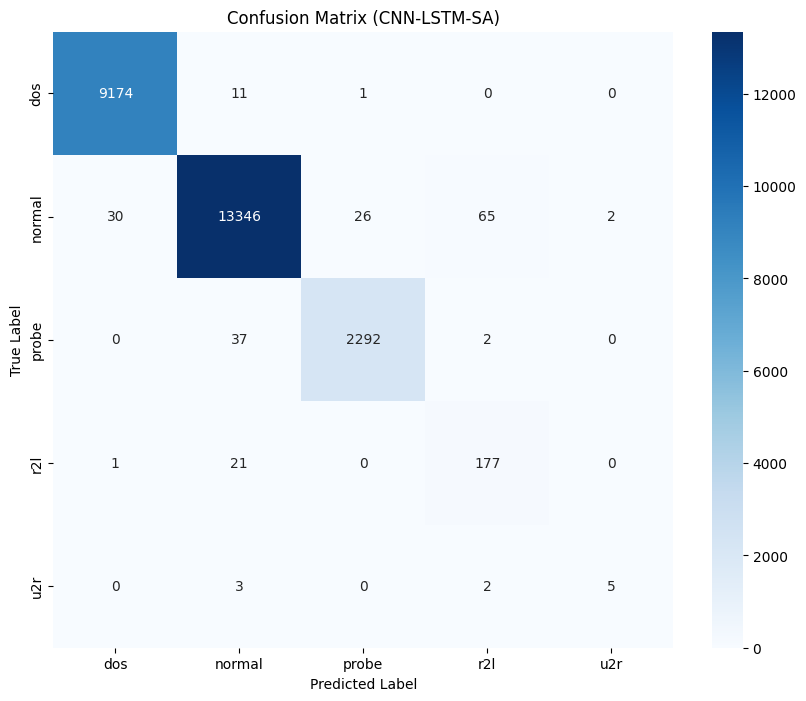

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 PAPER IMPLEMENTATION: CNN-LSTM-SA (11x11 Input) on: {device}")

# ==========================================
# 1. PAPER-SPECIFIC PREPROCESSING (121 Features -> 11x11)
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep_paper_style(path):
    print(f"Loading {path}...")
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print("⚠️ File not found. Using dummy data for structure check.")
        # Dummy data matching NSL-KDD structure
        cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]
        df = pd.DataFrame(np.random.randn(1000, 42), columns=cols)
        df['protocol_type'] = np.random.choice(['tcp', 'udp', 'icmp'], 1000)
        df['service'] = np.random.choice(['http', 'private', 'smtp'], 1000)
        df['flag'] = np.random.choice(['SF', 'S0', 'REJ'], 1000)
        df['label'] = np.random.choice(list(attack_map.keys()), 1000)

    # 1. Label Mapping
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    # 2. Drop unwanted columns (Paper explicitly removes 'num_outbound_cmds' to get 121 features)
    if 'num_outbound_cmds' in df.columns:
        df = df.drop('num_outbound_cmds', axis=1)
        
    # 3. Separate Target
    y = df['category']
    X = df.drop(['label', 'category'], axis=1)
    
    # 4. One-Hot Encoding (Protocol, Service, Flag)
    # Note: To strictly match 11x11 (121 features), we need exactly 121 columns after encoding.
    # Real NSL-KDD has specific counts. We will pad/truncate to ensure 121.
    X = pd.get_dummies(X, columns=['protocol_type', 'service', 'flag'])
    
    return X, y

# Load Data
try:
    X_raw, y_raw = load_and_prep_paper_style('Data/network_connections.csv')
except:
    X_raw, y_raw = load_and_prep_paper_style('network_connections.csv')

# --- ENFORCE 11x11 STRUCTURE (121 FEATURES) ---
# [cite_start]The paper insists on reshaping 1D vector to 11x11 matrix [cite: 127, 137]
REQUIRED_Feats = 121 

def enforce_feature_count(df_in, target_count):
    current_count = df_in.shape[1]
    if current_count < target_count:
        # Pad with zeros
        pad_cols = pd.DataFrame(0, index=df_in.index, columns=[f'pad_{i}' for i in range(target_count - current_count)])
        df_out = pd.concat([df_in, pad_cols], axis=1)
    elif current_count > target_count:
        # Truncate (keep first N)
        df_out = df_in.iloc[:, :target_count]
    else:
        df_out = df_in
    return df_out

X_fixed = enforce_feature_count(X_raw, REQUIRED_Feats)
print(f"Feature shape enforced to: {X_fixed.shape} (Must be N x 121)")

# Encode Labels
le = LabelEncoder()
y_vec = le.fit_transform(y_raw)
num_classes = len(le.classes_)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_fixed, y_vec, test_size=0.2, stratify=y_vec, random_state=42)

# [cite_start]Normalization (MinMax [0,1] as per paper eq. 1) [cite: 130]
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# [cite_start]Reshape to 11x11 Image format [cite: 127]
# PyTorch Conv2d expects: (Batch, Channel, Height, Width) -> (N, 1, 11, 11)
X_train_img = X_train_norm.reshape(-1, 1, 11, 11)
X_test_img = X_test_norm.reshape(-1, 1, 11, 11)

# Tensors
train_dataset = TensorDataset(torch.FloatTensor(X_train_img), torch.LongTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test_img), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

# ==========================================
# 2. ARCHITECTURE: CNN-LSTM-SA
# ==========================================
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(SelfAttention, self).__init__()
        # Simple self-attention: energy -> softmax -> context
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(True),
            nn.Linear(64, 1)
        )

    def forward(self, encoder_outputs):
        # encoder_outputs: [batch, seq_len, hidden_dim]
        energy = self.projection(encoder_outputs) # [batch, seq_len, 1]
        weights = F.softmax(energy.squeeze(-1), dim=1) # [batch, seq_len]
        # Context: Weighted Sum
        context = (encoder_outputs * weights.unsqueeze(-1)).sum(dim=1)
        return context

class CNN_LSTM_SA(nn.Module):
    def __init__(self, num_classes):
        super(CNN_LSTM_SA, self).__init__()
        
        # [cite_start]--- CNN Block (Feature Extraction) [cite: 235-240] ---
        # Paper uses 3 Conv layers: 32 -> 64 -> 128 filters with 2x2 kernels and MaxPool
        # Input: 1 x 11 x 11
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=2, padding=1) # Pad to keep size manageable
        self.pool1 = nn.MaxPool2d(2, 2) 
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=2, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # After 11x11 -> pool -> ~5x5 -> pool -> ~2x2 -> pool -> 1x1
        # We need to flatten for LSTM input sequence
        # The paper connects CNN output maps to LSTM
        
        # [cite_start]--- LSTM Block (Temporal Extraction) [cite: 241-243] ---
        # Paper uses 3 LSTM layers with 128 units
        # We treat the channel dimension (128) as features or sequence?
        # Typically CNN-LSTM flattens (Batch, Time, Feats). 
        # Here we interpret the 128 channels as the feature depth.
        self.lstm = nn.LSTM(input_size=128, hidden_size=128, num_layers=3, 
                            batch_first=True, dropout=0.2)
        
        # [cite_start]--- Attention Block [cite: 245] ---
        self.attention = SelfAttention(hidden_dim=128)
        
        # [cite_start]--- Classification [cite: 246] ---
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: [Batch, 1, 11, 11]
        
        # CNN Part
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x) 
        # Output shape approx: [Batch, 128, 1, 1] (depending on exact padding/pooling)
        
        # Prepare for LSTM
        # Reshape to [Batch, Seq_Len=1, Features=128] or similar
        # Since spatial dims are collapsed to ~1x1, we treat it as a sequence of length 1?
        # Or we view the 128 channels as the sequence? 
        # The paper mentions "temporal feature extraction".
        # Let's reshape to [Batch, 1, 128] for compatibility
        x = x.view(x.size(0), -1, 128) 
        
        # LSTM Part
        x, _ = self.lstm(x) # Output: [Batch, Seq_Len, 128]
        
        # Attention Part
        x = self.attention(x) # Output: [Batch, 128]
        
        # Output Part
        logits = self.fc(x)
        return logits

# ==========================================
# 3. TRAINING LOOP
# ==========================================
model = CNN_LSTM_SA(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n--- STARTING TRAINING (Paper Method) ---")
for epoch in range(15):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    acc = 100 * correct / total
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {acc:.2f}%")

# ==========================================
# 4. EVALUATION (Metrics as requested)
# ==========================================
print("\n--- FINAL EVALUATION ---")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

# Metrics
acc = accuracy_score(all_targets, all_preds)
mcc = matthews_corrcoef(all_targets, all_preds)

print("-" * 40)
print(f"✅ MODEL: CNN-LSTM-SA (Paper Implementation)")
print(f"📊 ACCURACY: {acc:.2%}")
print(f"📉 MCC SCORE: {mcc:.4f}")
print("-" * 40)

print("\nDetailed Classification Report:")
print(classification_report(all_targets, all_preds, target_names=le.classes_))

# Confusion Matrix
labels = sorted(list(set(all_targets) | set(all_preds)))
label_names = [le.classes_[i] for i in labels]

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(all_targets, all_preds, labels=labels), 
            annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix (CNN-LSTM-SA)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


--- 🧪 STARTING EVALUATION ON KDDTest+ ---
📥 Downloading KDDTest+ from https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt...
✅ Loaded KDDTest+: (22544, 43)
⚙️ Aligning features to training set structure...
🚀 Running Inference on KDDTest+...

🏆 FINAL KDDTest+ RESULTS (CNN-LSTM-SA)
📊 ACCURACY: 75.07%
📉 MCC SCORE: 0.6380
--------------------------------------------------
Detailed Classification Report:

              precision    recall  f1-score   support

         dos       0.96      0.74      0.84      7458
      normal       0.66      0.94      0.77      9711
       probe       0.73      0.81      0.77      2421
         r2l       0.97      0.12      0.22      2887
         u2r       0.61      0.16      0.26        67

    accuracy                           0.75     22544
   macro avg       0.79      0.55      0.57     22544
weighted avg       0.81      0.75      0.72     22544



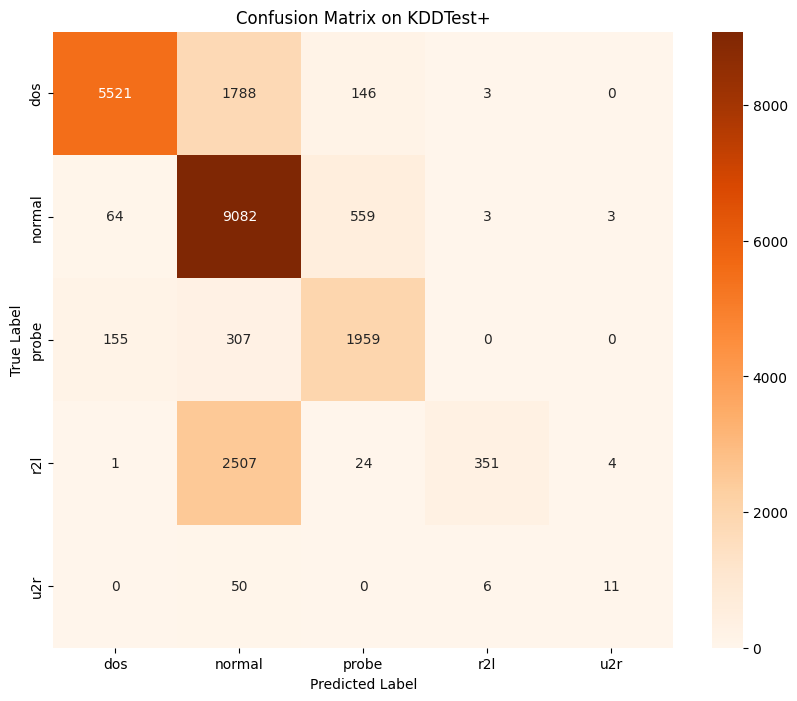

In [2]:
# ==========================================
# 5. EVALUATION ON NSL-KDD TEST+ (The "Other" Dataset)
# ==========================================
print("\n--- 🧪 STARTING EVALUATION ON KDDTest+ ---")

# 1. Load Official Test Set
test_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
           "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
           "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
           "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

try:
    print(f"📥 Downloading KDDTest+ from {test_url}...")
    df_test = pd.read_csv(test_url, header=None, names=columns)
    print(f"✅ Loaded KDDTest+: {df_test.shape}")
except Exception as e:
    print(f"❌ Error downloading: {e}")
    # Fallback if offline
    df_test = pd.DataFrame(columns=columns) # Empty dummy

# 2. Preprocessing (MUST MATCH TRAINING EXACTLY)
# A. Map Labels
df_test['label'] = df_test['label'].astype(str).str.replace('.', '', regex=False)
df_test['category'] = df_test['label'].map(attack_map).fillna('other')

# B. Drop unused columns
if 'difficulty' in df_test.columns:
    df_test = df_test.drop('difficulty', axis=1)
if 'num_outbound_cmds' in df_test.columns:
    df_test = df_test.drop('num_outbound_cmds', axis=1)

y_test_real = df_test['category']
X_test_real = df_test.drop(['label', 'category'], axis=1)

# C. One-Hot Encoding
X_test_real = pd.get_dummies(X_test_real, columns=['protocol_type', 'service', 'flag'])

# D. ALIGN FEATURES with Training Data
# (Crucial: Test set might have different services/flags than Train. 
# We reindex to match X_fixed from training block exactly, filling missing with 0)
print("⚙️ Aligning features to training set structure...")
# X_fixed comes from your previous training block
train_cols = X_fixed.columns 
X_test_aligned = X_test_real.reindex(columns=train_cols, fill_value=0)

# E. Enforce 121 Count (Padding/Truncating if reindex didn't catch everything)
X_test_final = enforce_feature_count(X_test_aligned, 121)

# F. Scale & Reshape
# Use the SAME scaler from training!
X_test_real_norm = scaler.transform(X_test_final) 
# Reshape to 11x11 Image
X_test_real_img = X_test_real_norm.reshape(-1, 1, 11, 11)

# G. Encode Labels
# Handle unseen labels by mapping them to a known class or ignoring (here we assume 'other' catches them)
# Note: KDDTest+ has attack types not in Train. attack_map handles most, but 'le' needs to be robust.
# We use the 'le' fitted on training.
y_test_real_vec = y_test_real.apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values

# Filter out -1 (unknown classes) if any remain, though attack_map usually covers them
mask = y_test_real_vec != -1
X_test_real_img = X_test_real_img[mask]
y_test_real_vec = y_test_real_vec[mask]

# 3. Create DataLoader
real_test_dataset = TensorDataset(torch.FloatTensor(X_test_real_img), torch.LongTensor(y_test_real_vec))
real_test_loader = DataLoader(real_test_dataset, batch_size=512, shuffle=False)

# 4. Run Inference
model.eval()
kdd_preds = []
kdd_targets = []

print("🚀 Running Inference on KDDTest+...")
with torch.no_grad():
    for x_b, y_b in real_test_loader:
        x_b = x_b.to(device)
        outputs = model(x_b)
        _, preds = torch.max(outputs, 1)
        
        kdd_preds.extend(preds.cpu().numpy())
        kdd_targets.extend(y_b.numpy())

# 5. Metrics
acc_kdd = accuracy_score(kdd_targets, kdd_preds)
mcc_kdd = matthews_corrcoef(kdd_targets, kdd_preds)

print("\n" + "="*50)
print(f"🏆 FINAL KDDTest+ RESULTS (CNN-LSTM-SA)")
print("="*50)
print(f"📊 ACCURACY: {acc_kdd:.2%}")
print(f"📉 MCC SCORE: {mcc_kdd:.4f}")
print("-" * 50)
print("Detailed Classification Report:\n")
print(classification_report(kdd_targets, kdd_preds, target_names=le.classes_))

# 6. Confusion Matrix
plt.figure(figsize=(10,8))
labels = sorted(list(set(kdd_targets) | set(kdd_preds)))
label_names = [le.classes_[i] for i in labels]
sns.heatmap(confusion_matrix(kdd_targets, kdd_preds, labels=labels), 
            annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix on KDDTest+')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()